Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\Data-20260508T135348Z-3-001\\Data\\newsData\\raw_analyst_ratings.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


5. Descriptive Statistics

In [3]:
df['headline_length'] = df['headline'].astype(str).apply(len)
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Publisher count:

In [4]:
df['publisher'].value_counts().head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Visualization:

<Axes: xlabel='publisher'>

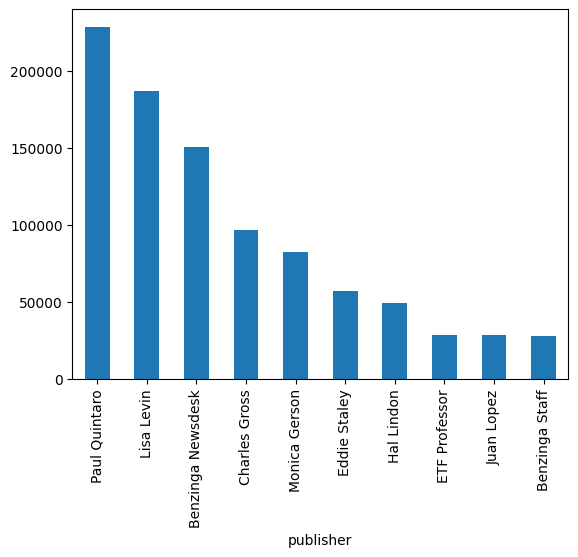

In [5]:
df['publisher'].value_counts().head(10).plot(kind='bar')

6. Keyword / Topic Analysis

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['headline'])

words = vectorizer.get_feature_names_out()

Most common words:

In [7]:
import numpy as np

counts = X.sum(axis=0).A1
freq = pd.DataFrame({'word': words, 'count': counts})
freq.sort_values(by='count', ascending=False).head(20)

,word,count
104259,vs,162099
93662,stocks,161776
40857,est,140604
40388,eps,128897
63981,market,120558
89240,shares,114313
83568,reports,108710
101800,update,91723
37999,earnings,87399
86676,sales,79645


7. Time Series Analysis

Convert date:

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')


Articles over time:

<Axes: xlabel='date'>

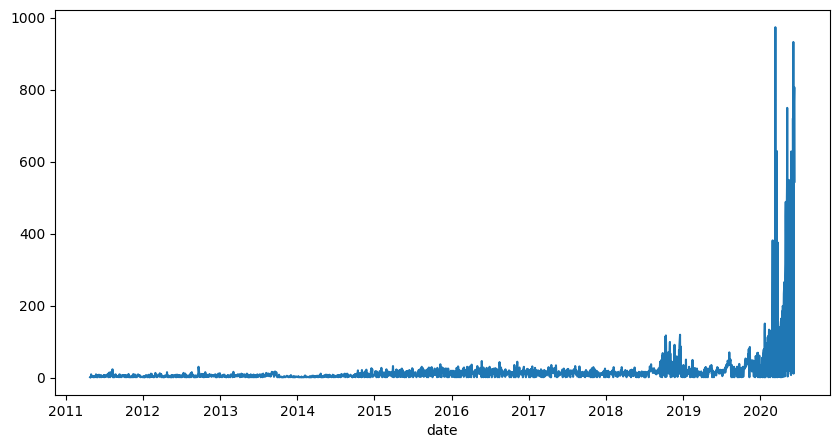

In [10]:
daily = df.groupby(df['date'].dt.date).size()

daily.plot(figsize=(10,5))

Publishing hour:

<Axes: xlabel='hour'>

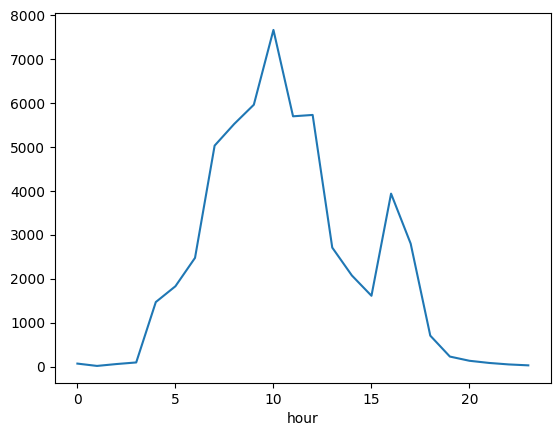

In [11]:
df['hour'] = df['date'].dt.hour
df['hour'].value_counts().sort_index().plot()

8. Publisher Domain Analysis

In [12]:
df['domain'] = df['publisher'].astype(str).str.extract(r'@(.+)')
df['domain'].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64